# Analysis and Visualizations of Experiment 1 Results

The analysis from this notebook will make up the figures and results for Experiment 1

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../Experiment 1/dataset/experiment1_result.csv')

display(df)

,Experiment,Algorithm,Grid_Size,Density,Execution_Time,Nodes_Expanded,Path_Length,Memory_B,Success(%)
0,1,BFS,10x10,10,0.549±0.477,88.448±3.841,10.517±0.509,4324.966±123.943,96.7
1,1,BFS,30x30,15,3.842±0.612,765.233±11.855,32.167±0.747,36753.600±564.034,100.0
2,1,BFS,50x50,20,13.807±4.161,1996.833±19.402,54.433±1.194,95888.000±949.878,100.0
3,1,Dijkstra,10x10,10,0.626±0.217,90.200±3.145,10.733±0.583,4329.600±150.950,100.0
4,1,Dijkstra,30x30,15,4.736±1.526,765.333±10.357,32.333±0.802,36740.800±487.503,100.0
5,1,Dijkstra,50x50,20,14.712±2.367,2003.967±23.442,54.833±1.147,96195.333±1122.066,100.0
6,1,A*,10x10,10,0.428±0.299,17.700±8.163,10.600±0.563,2182.400±320.320,100.0
7,1,A*,30x30,15,1.773±1.106,114.900±51.039,32.067±0.828,9872.000±2466.940,100.0
8,1,A*,50x50,20,5.583±1.986,425.345±93.883,55.034±0.944,27074.207±4321.235,96.7
9,1,D*_Lite,10x10,10,0.957±0.487,16.733±6.581,10.600±0.563,2152.267±253.666,100.0


#### Runtime Analysis by Grid Size

In [4]:
df = pd.read_csv('../Experiment 1/dataset/experiment1_result.csv')

# Extract numeric means
df['Exec_Mean'] = df['Execution_Time'].str.split('±').str[0].astype(float)
df['Mem_Mean'] = df['Memory_B'].str.split('±').str[0].astype(float)

# Prepare Table 4.6 (Runtime)
df_exec = df.pivot(index='Grid_Size', columns='Algorithm', values='Execution_Time')

# Pivot for means
df_exec_means = df.pivot(index='Grid_Size', columns='Algorithm', values='Exec_Mean')

# Force numeric conversion on all columns
for col in df_exec_means.columns:
    df_exec_means[col] = pd.to_numeric(df_exec_means[col])

# Perform operation
df_exec_means['Fastest'] = df_exec_means.idxmin(axis=1)
df_exec_means['Min_Val'] = df_exec_means[['A*', 'BFS', 'D*_Lite', 'Dijkstra']].min(axis=1)
df_exec_means['Speedup_vs_BFS'] = df_exec_means['BFS'] / df_exec_means['Min_Val']

#print(df_exec_means.head())

# Re-prepare Tables for Markdown
# Re-pivot Execution Time string values
df_exec = df.pivot(index='Grid_Size', columns='Algorithm', values='Execution_Time')
run_time_df = df_exec.copy()
run_time_df = run_time_df[['BFS', 'Dijkstra', 'A*', 'D*_Lite']]
run_time_df['Fastest Algorithm'] = df_exec_means['Fastest']
run_time_df['Speedup vs BFS'] = df_exec_means['Speedup_vs_BFS'].round(3)
run_time_df = run_time_df.reset_index()

# Prepare Table 4.7 (Memory)
df_mem = df.pivot(index='Grid_Size', columns='Algorithm', values='Memory_B')
memory_df = df_mem.copy()
memory_df = memory_df[['BFS', 'Dijkstra', 'A*', 'D*_Lite']]
memory_df['Growth Pattern'] = "$O(N^2)$ expected"
memory_df = memory_df.reset_index()

print("Runtime Analysis Table:")
display(run_time_df)
print("\nMemory Analysis Table:")
display(memory_df)


Runtime Analysis Table:


Algorithm,Grid_Size,BFS,Dijkstra,A*,D*_Lite,Fastest Algorithm,Speedup vs BFS
0,10x10,0.549±0.477,0.626±0.217,0.428±0.299,0.957±0.487,A*,1.283
1,30x30,3.842±0.612,4.736±1.526,1.773±1.106,4.927±1.781,A*,2.167
2,50x50,13.807±4.161,14.712±2.367,5.583±1.986,11.133±3.746,A*,2.473



Memory Analysis Table:


Algorithm,Grid_Size,BFS,Dijkstra,A*,D*_Lite,Growth Pattern
0,10x10,4324.966±123.943,4329.600±150.950,2182.400±320.320,2152.267±253.666,$O(N^2)$ expected
1,30x30,36753.600±564.034,36740.800±487.503,9872.000±2466.940,10571.267±2154.141,$O(N^2)$ expected
2,50x50,95888.000±949.878,96195.333±1122.066,27074.207±4321.235,26963.586±5538.034,$O(N^2)$ expected


## Visualizations

In [5]:
# Process the data
df = pd.read_csv('../Experiment 1/dataset/experiment1_result.csv')
# Split '±' columns into mean and std
for col in ['Execution_Time', 'Nodes_Expanded', 'Path_Length', 'Memory_B']:
    df[[f'{col}_mean', f'{col}_std']] = df[col].str.split('±', expand=True).astype(float)

# Add numeric grid size (e.g., 10x10 -> 100 or simply 10 for X-axis)
df['N'] = df['Grid_Size'].str.split('x').str[0].astype(int)
df['N'] = df['N'] ** 2

display(df)

,Experiment,Algorithm,Grid_Size,Density,Execution_Time,Nodes_Expanded,Path_Length,Memory_B,Success(%),Execution_Time_mean,Execution_Time_std,Nodes_Expanded_mean,Nodes_Expanded_std,Path_Length_mean,Path_Length_std,Memory_B_mean,Memory_B_std,N
0,1,BFS,10x10,10,0.549±0.477,88.448±3.841,10.517±0.509,4324.966±123.943,96.7,0.549,0.477,88.448,3.841,10.517,0.509,4324.966,123.943,100
1,1,BFS,30x30,15,3.842±0.612,765.233±11.855,32.167±0.747,36753.600±564.034,100.0,3.842,0.612,765.233,11.855,32.167,0.747,36753.600,564.034,900
2,1,BFS,50x50,20,13.807±4.161,1996.833±19.402,54.433±1.194,95888.000±949.878,100.0,13.807,4.161,1996.833,19.402,54.433,1.194,95888.000,949.878,2500
3,1,Dijkstra,10x10,10,0.626±0.217,90.200±3.145,10.733±0.583,4329.600±150.950,100.0,0.626,0.217,90.200,3.145,10.733,0.583,4329.600,150.950,100
4,1,Dijkstra,30x30,15,4.736±1.526,765.333±10.357,32.333±0.802,36740.800±487.503,100.0,4.736,1.526,765.333,10.357,32.333,0.802,36740.800,487.503,900
5,1,Dijkstra,50x50,20,14.712±2.367,2003.967±23.442,54.833±1.147,96195.333±1122.066,100.0,14.712,2.367,2003.967,23.442,54.833,1.147,96195.333,1122.066,2500
6,1,A*,10x10,10,0.428±0.299,17.700±8.163,10.600±0.563,2182.400±320.320,100.0,0.428,0.299,17.700,8.163,10.600,0.563,2182.400,320.320,100
7,1,A*,30x30,15,1.773±1.106,114.900±51.039,32.067±0.828,9872.000±2466.940,100.0,1.773,1.106,114.900,51.039,32.067,0.828,9872.000,2466.940,900
8,1,A*,50x50,20,5.583±1.986,425.345±93.883,55.034±0.944,27074.207±4321.235,96.7,5.583,1.986,425.345,93.883,55.034,0.944,27074.207,4321.235,2500
9,1,D*_Lite,10x10,10,0.957±0.487,16.733±6.581,10.600±0.563,2152.267±253.666,100.0,0.957,0.487,16.733,6.581,10.600,0.563,2152.267,253.666,100


#### Runtime Analysis Visualizations

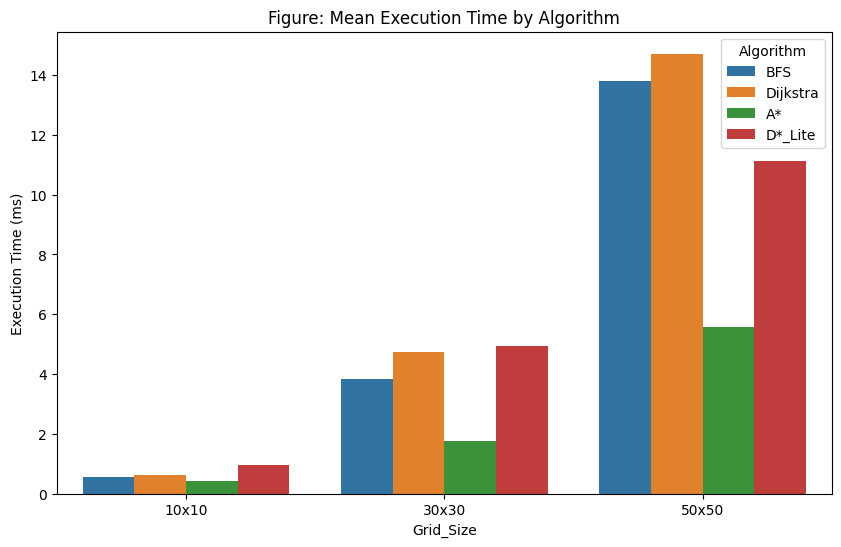

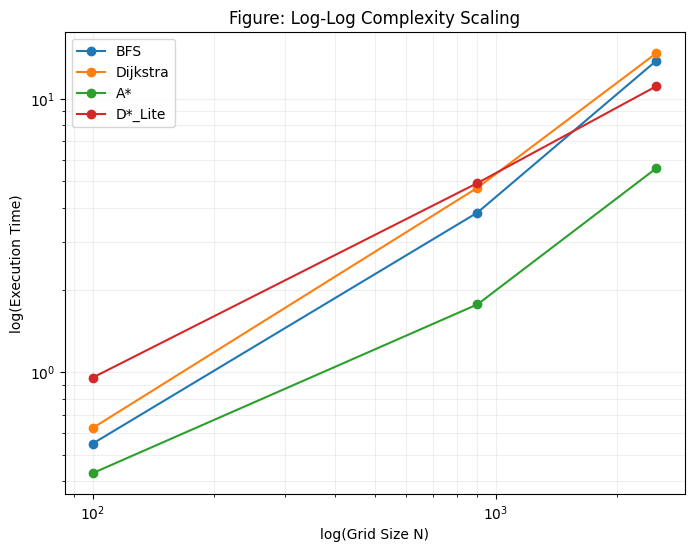

In [6]:
# Figure 4.2.1: Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Grid_Size', y='Execution_Time_mean', hue='Algorithm', capsize=.1)
plt.title('Figure: Mean Execution Time by Algorithm')
plt.ylabel('Execution Time (ms)')
plt.show()

# Figure 4.2.2: Log-Log Complexity Scaling
plt.figure(figsize=(8, 6))
for algo in df['Algorithm'].unique():
    subset = df[df['Algorithm'] == algo]
    plt.loglog(subset['N'], subset['Execution_Time_mean'], marker='o', label=algo)

plt.title('Figure: Log-Log Complexity Scaling')
plt.xlabel('log(Grid Size N)')
plt.ylabel('log(Execution Time)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

#### Memory Analysis (Peak Memory Usage) Visualization

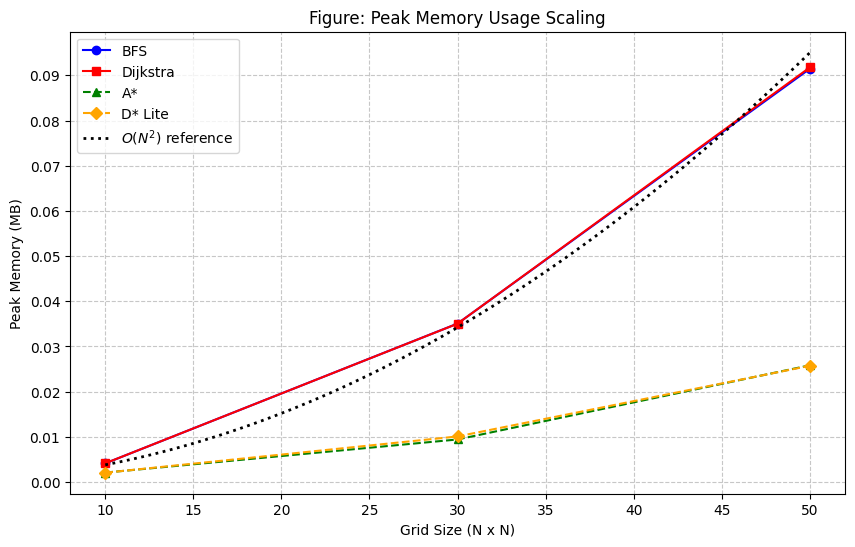

In [7]:
# Process Memory
df['Mem_Mean'] = df['Memory_B'].str.split('±').str[0].astype(float)
df['Memory_MB'] = df['Mem_Mean'] / (1024 * 1024)
df['N'] = df['Grid_Size'].str.split('x').str[0].astype(int)

# Plotting
plt.figure(figsize=(10, 6))

algorithms = df['Algorithm'].unique()
styles = {
    'BFS': {'linestyle': '-', 'color': 'blue', 'marker': 'o', 'label': 'BFS'},
    'Dijkstra': {'linestyle': '-', 'color': 'red', 'marker': 's', 'label': 'Dijkstra'},
    'A*': {'linestyle': '--', 'color': 'green', 'marker': '^', 'label': 'A*'},
    'D*_Lite': {'linestyle': '--', 'color': 'orange', 'marker': 'D', 'label': 'D* Lite'}
}

for algo in algorithms:
    subset = df[df['Algorithm'] == algo].sort_values('N')
    plt.plot(subset['N'], subset['Memory_MB'], 
             linestyle=styles[algo]['linestyle'], 
             color=styles[algo]['color'], 
             marker=styles[algo]['marker'], 
             label=styles[algo]['label'])

# Set Y-ticks to be more granular
plt.yticks(np.arange(0, 0.11, 0.01))

# O(N^2) Reference Curve
x_vals = np.linspace(10, 50, 100)
y_ref = 3.8e-5 * (x_vals**2)
plt.plot(x_vals, y_ref, 'k:', label='$O(N^2)$ reference', linewidth=2)

plt.title('Figure: Peak Memory Usage Scaling')
plt.xlabel('Grid Size (N x N)')
plt.ylabel('Peak Memory (MB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)